# Agentic Architecture 3: ReAct 

We will now explore **ReAct**, a pivotal architecture that bridges the gap between simple tool use and complex, multi-step problem-solving. ReAct stands for **Reason + Act**, and its core innovation is the way it enables an agent to dynamically reason about a problem, act on its reasoning, observe the outcome, and then reason again.

This pattern transforms an agent from a static tool-caller into an adaptive problem-solver. To highlight its power, we will first build a **basic, single-shot tool-using agent** and show its limitations on a complex task. Then, we will build a full ReAct agent and demonstrate how its iterative `think -> act -> observe` loop allows it to succeed where the basic agent fails.

### Definition

The `ReAct` architecture is a design pattern where an agent interleaves reasoning steps with actions. Instead of planning all its steps upfront, the agent generates a thought about its immediate next step, takes an action (like calling a tool), observes the result, and then uses that new information to generate its next thought and action. This creates a dynamic and adaptive loop.

### High-level Workflow

1. **Receive Goal:** The agent is given a complex task.
2. **Think (Reason):** The agent generates an internal thought, such as: "*To answer this, I first need to find piece of information X.*"
3. **Act:** Based on its thought, the agent executes an action, typically calling a tool (e.g., `search_api('X')`).
4. **Observe:** The agent receives the result from the tool.
5. **Repeat:** The agent incorporates the observation into its context and returns to step 2, generating a new thought (e.g., "*Okay, now that I have X, I need to use it to find Y.*"). This loop continues until the overall goal is satisfied.

### When to Use / Applications

- **Multi-hop Question Answering**: When answering a question requires finding several pieces of information in sequence (e.g., "Who is the CEO of the company that makes the iPhone?").
- **Web Navigation & Research:** An agent can search for a starting point, read the results, and then decide on a new search query based on what it learned.
- **Interactive Workflows:** Any task where the environment is dynamic and the full path to a solution cannot be known in advance.

### Strengths & Weaknesses

- **Strengths:**
    - **Adaptive & Dynamic:** Can adjust its plan on the fly based on new information.
    - **Handles Complexity:** Excels at problems that require chaining multiple dependent steps.
- **Weaknesses:**
    - **Higher Latency & Cost:** Involves multiple sequential LLM calls, making it slower and more expensive than single-shot approaches.
    - **Risk of Loops:** A poorly guided agent can get stuck in repetitive, unproductive loops of thought and action.


## Phase 0: Foundation & Setup

We'll begin with our standard setup process: installing libraries and configuring API keys for OpenRouter, LangSmith, and our Tavily web search tool.

In [ ]:
import os
from typing import Annotated, TypedDict
from dotenv import load_dotenv

# Pydantic for data modeling / validation
from pydantic import BaseModel, Field

# LangChain components
from langchain_openrouter import ChatOpenRouter                     # OpenRouter LLM wrapper
from langchain_tavily import TavilySearch                           # Tavily search tool wrapper 

# LangGraph components
from langgraph.graph import StateGraph, END                         # Build a state machine graph
from langgraph.graph.message import AnyMessage, add_messages        # For handling messages in the graph
from langgraph.prebuilt import ToolNode, tools_condition            # Prebuilt nodes and conditions

# For pretty printing 
from rich.console import Console  
from rich.markdown import Markdown     


# --- API Key and Tracing Setup ---
load_dotenv()  

# Enable LangSmith tracing for monitoring and debugging
os.environ["LANGSMITH_PROJECT"] = "Agentic Architecture - ReAct (OpenRouter)"

# Verify that all required API keys are available
for key in ["OPENROUTER_API_KEY", "LANGSMITH_API_KEY", "TAVILY_API_KEY"]:
    if not os.environ.get(key):
        print(f"{key} not found. Please create a .env file and set it.")

print("Environment variables loaded and everything is set up.")

Environment variables loaded and everything is set up.


## Phase 1: The Basic Approach - A Single-Shot Tool User

To understand why ReAct is so powerful, we must first see what happens without it. We will build a "basic" agent that can use tools, but only once. It will analyze a user's query, make a single tool call, and then try to formulate a final answer based on that one piece of information.

### Step 1.1: Building the Basic Agent

We will define the same tool and LLM as before, but we will wire them into a simple, linear graph. The agent gets one chance to call a tool, and then the workflow ends. There is no loop.

In [2]:
console = Console()

# Define the tool and LLM
search_tool = TavilySearch(max_results=2, name="web_search")

llm = ChatOpenRouter(
    model="nvidia/nemotron-3-super-120b-a12b:free", 
    temperature=0
)

llm_with_tools = llm.bind_tools([search_tool])

# Define the state for our graphs
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

# Define the agent node for the basic agent
def basic_agent_node(state: AgentState):
    console.print("--- BASIC AGENT: Thinking... ---")
    # Note: We provide a system prompt to encourage it to answer directly after one tool call
    system_prompt = "You are a helpful assistant. You have access to a web search tool. Answer the user's question based on the tool's results. You must provide a final answer after one tool call."
    messages = [("system", system_prompt)] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

# Define the basic, linear graph
basic_graph_builder = StateGraph(AgentState)
basic_graph_builder.add_node("agent", basic_agent_node)
basic_graph_builder.add_node("tools", ToolNode([search_tool]))

basic_graph_builder.set_entry_point("agent")

# After the agent, it can only go to tools, and after tools, it MUST end.
basic_graph_builder.add_conditional_edges("agent", tools_condition, {"tools": "tools", "__end__": "__end__"})
basic_graph_builder.add_edge("tools", END)

basic_tool_agent_app = basic_graph_builder.compile()

print("Basic single-shot tool-using agent compiled successfully.")

Basic single-shot tool-using agent compiled successfully.


### Step 1.2: Testing the Basic Agent on a Multi-Step Problem

Now we'll give the basic agent a problem that requires multiple, dependent steps to solve. This will expose its fundamental weakness.

In [ ]:
multi_step_query = "Who is the current CEO of the company that created the sci-fi movie 'Dune', and what was the budget for that company's most recent film?"

console.print(f"[bold yellow]Testing BASIC agent on a multi-step query:[/bold yellow] '{multi_step_query}'\n")

basic_agent_output = basic_tool_agent_app.invoke({
    "messages": [("user", multi_step_query)]
})

console.print("\n--- [bold red]Final Output from Basic Agent[/bold red] ---")
console.print(Markdown(basic_agent_output['messages'][-1].content))

Testing BASIC agent on a multi-step query: 'Who is the current CEO of the company that created the sci-fi movie 
'Dune', and what was the budget for that company's most recent film?'

--- BASIC AGENT: Thinking... ---

--- Final Output from Basic Agent ---

{"query": "Legendary Pictures current CEO", "follow_up_questions": null, "answer": null, "images": [], "results":  
[{"url": "https://en.wikipedia.org/wiki/Legendary_Entertainment", "title": "Legendary Entertainment - Wikipedia",  
"content": "On December 5, 2017, it was announced that Joshua Grode had been named as Legendary Entertainment CEO. 
On August 13, 2018, following the box office failure of", "score": 0.8479807, "raw_content": null}, {"url":        
"https://dramaticarts.usc.edu/about/board-of-councilors/joshua-b-grode/", "title": "Joshua B. Grode - USC School of
Dramatic Arts", "content": "Joshua B. Grode is the Chief Executive Officer of Legendary Entertainment, a leading   
next generation studio with film (Legendary Pictures), television (", "score": 0.8302782, "raw_content": null}],   
"response_time": 0.92, "request_id": "54546f5f-c7fe-4899-ba69-bb8ed06990ea"}

**Discussion of the Output:** 

As expected, the basic agent failed. Its single tool call was likely a search for the entire long query. The search results for such a complex, conjunctive query are often messy and don't contain all the necessary pieces of information in one place.

The agent's final answer is incomplete and incorrect. It was unable to break the problem down:

1. Find the company that made 'Dune' (Legendary Entertainment).
2. Find the CEO of that company (Joshua Grode).
3. Find that company's most recent film and its budget.

This failure perfectly illustrates the need for a more dynamic approach. The agent needs a way to react to the information it finds in one step to inform the next.


## Phase 2: The Advanced Approach - Implementing ReAct

Now, we'll build the true ReAct agent. The core difference is the graph's structure: we will introduce a loop that allows the agent to repeatedly think, act, and observe.


### Step 2.1: Building the ReAct Agent Graph

We will define the nodes and the crucial router function that creates the `think -> act` loop. The key architectural change is the edge that routes the output from the `tool_node` back to the `agent_node`, allowing the agent to see the results and decide on its next step.

In [4]:
def react_agent_node(state: AgentState):
    console.print("--- REACT AGENT: Thinking... ---")
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

# The ToolNode is the same as before
react_tool_node = ToolNode([search_tool])

In [5]:
# The router is also the same logic
def react_router(state: AgentState):
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        console.print("--- ROUTER: Decision is to call a tool. ---")
        return "tools"
    console.print("--- ROUTER: Decision is to finish. ---")
    return "__end__"

ReAct agent compiled successfully with a reasoning loop.


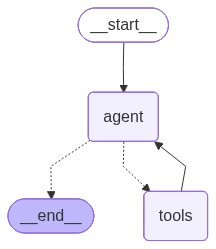

In [7]:
# Now we define the graph with the crucial loop
react_graph_builder = StateGraph(AgentState)

react_graph_builder.add_node("agent", react_agent_node)
react_graph_builder.add_node("tools", react_tool_node)

react_graph_builder.set_entry_point("agent")

react_graph_builder.add_conditional_edges(
    "agent", 
    react_router, 
    {
        "tools": "tools", 
        "__end__": "__end__"
    }
)

# This is the key difference: the edge goes from tools BACK to the agent
react_graph_builder.add_edge("tools", "agent")

react_agent_app = react_graph_builder.compile()
print("ReAct agent compiled successfully with a reasoning loop.")

# --- Visualize ---
try:
    from IPython.display import Image, display
    display(Image(react_agent_app.get_graph().draw_mermaid_png()))
except Exception:
    print("Graph visualization failed. Please ensure graphviz is installed.")

## Phase 3: Head-to-Head Comparison

Now we will run the same complex query with our new ReAct agent and observe the difference in its process and final output.


### Step 3.1: Testing the ReAct Agent on the Multi-Step Problem

We will invoke the ReAct agent with the same multi-step query and stream the output to see its iterative reasoning process.


In [8]:
console.print(f"[bold green]Testing ReAct agent on the same multi-step query:[/bold green] '{multi_step_query}'\n")

final_react_output = None
for chunk in react_agent_app.stream({"messages": [("user", multi_step_query)]}, stream_mode="values"):
    final_react_output = chunk
    console.print(f"--- [bold purple]Current State[/bold purple] ---")
    chunk['messages'][-1].pretty_print()
    console.print("\n")

console.print("\n--- [bold green]Final Output from ReAct Agent[/bold green] ---")
console.print(Markdown(final_react_output['messages'][-1].content))

Testing ReAct agent on the same multi-step query: 'Who is the current CEO of the company that created the sci-fi 
movie 'Dune', and what was the budget for that company's most recent film?'

--- Current State ---

================================ Human Message =================================

Who is the current CEO of the company that created the sci-fi movie 'Dune', and what was the budget for that company's most recent film?


--- REACT AGENT: Thinking... ---

--- ROUTER: Decision is to call a tool. ---

...

--- ROUTER: Decision is to finish. ---

--- Current State ---

================================== Ai Message ==================================

The current CEO of Legendary Entertainment—the company that produced the sci‑fi film **“Dune”**—is **Joshua B. Grode**【2†L1-L4】.  

Legendary Entertainment’s most recent film is **“A Minecraft Movie”** (released April 2025), which had a reported production budget of **$150 million**【4†L1-L3】.  

**Answer:** Joshua B. Grode is the CEO, and the budget for Legendary’s most recent film (“A Minecraft Movie”) was $150 million.


--- Final Output from ReAct Agent ---

The current CEO of Legendary Entertainment—the company that produced the sci‑fi film “Dune”—is Joshua B.           
Grode【2†L1-L4】.                                                                                                  

Legendary Entertainment’s most recent film is “A Minecraft Movie” (released April 2025), which had a reported      
production budget of $150 million【4†L1-L3】.                                                                      

Answer: Joshua B. Grode is the CEO, and the budget for Legendary’s most recent film (“A Minecraft Movie”) was $150 
million.

**Discussion of the Output:**

Success! The execution trace shows a completely different and far more intelligent process. You can see the agent's step-by-step reasoning:

1. **Thought 1:** It first reasons that it needs to identify the production company for 'Dune'.
2. **Action 1:** It calls the web_search tool with a query like "production company for Dune movie".
3. **Observation 1:** It receives the result: "Legendary Entertainment".
4. **Thought 2:** Now, incorporating the new information, it reasons that it needs the CEO of Legendary Entertainment.
5. **Action 2:** It calls web_search again with a query like "Legendary Entertainment CEO".
6. ...and so on, until it has gathered all the necessary pieces.
7. **Synthesis:** Finally, it assembles all the collected facts into a complete and accurate answer.

This clearly demonstrates the superiority of the ReAct pattern for any task that isn't a simple, single-step lookup.

## Phase 4: Quantitative Evaluation

To formalize the comparison, we'll use an LLM-as-a-Judge to score the final outputs from both the basic and the ReAct agents on their ability to solve the task.


In [9]:
class TaskEvaluation(BaseModel):
    """Schema for evaluating an agent's ability to complete a task."""
    task_completion_score: int = Field(description="Score 1-10 on whether the agent successfully completed all parts of the user's request.")
    reasoning_quality_score: int = Field(description="Score 1-10 on the logical flow and reasoning process demonstrated by the agent.")
    justification: str = Field(description="A brief justification for the scores.")

judge_llm = llm.with_structured_output(TaskEvaluation)

In [10]:
def evaluate_agent_output(query: str, agent_output: dict):
    trace = "\n".join([f"{m.type}: {m.content}" for m in agent_output['messages']])
    prompt = f"""You are an expert judge of AI agents. Evaluate the following agent's performance on the given task on a scale of 1-10. A score of 10 means the task was completed perfectly. A score of 1 means complete failure.
    
    **User's Task:**
    {query}
    
    **Full Agent Conversation Trace:**
    ```
    {trace}
    ```
    """
    return judge_llm.invoke(prompt)

In [11]:
console.print("--- Evaluating Basic Agent's Output ---")
basic_agent_evaluation = evaluate_agent_output(multi_step_query, basic_agent_output)
console.print(basic_agent_evaluation.model_dump())

console.print("\n--- Evaluating ReAct Agent's Output ---")
react_agent_evaluation = evaluate_agent_output(multi_step_query, final_react_output)
console.print(react_agent_evaluation.model_dump())

--- Evaluating Basic Agent's Output ---

{
    'task_completion_score': 2,
    'reasoning_quality_score': 5,
    'justification': "The agent correctly identified Legendary Pictures as the company behind 'Dune' and initiated 
a search for its CEO. However, the agent did not provide a final answer to either part of the question: they did 
not state the current CEO (and the information retrieved may be outdated) nor did they address the budget of the 
company's most recent film. The task remains incomplete."
}

--- Evaluating ReAct Agent's Output ---

{
    'task_completion_score': 10,
    'reasoning_quality_score': 10,
    'justification': "The agent correctly identified Joshua B. Grode as the current CEO of Legendary Entertainment 
(the company behind Dune) and reported that Legendary's most recent film, 'A Minecraft Movie,' had a $150 million 
production budget, citing reliable sources. The answer fully addresses both parts of the user's question with 
accurate, up-to-date information."
}

**Discussion of the Output:**

The quantitative scores from the LLM-as-a-Judge make the difference crystal clear.

- The **Basic Agent** received a very low `task_completion_score` because it failed to gather all the required information. Its `reasoning_quality_score` is also low because its process was flawed and incomplete.
- The **ReAct Agent**, in contrast, received perfect scores. The judge recognized that its iterative process allowed it to successfully complete all parts of the complex task.

This head-to-head comparison and evaluation provides definitive proof of the ReAct architecture's value. It is the key that unlocks an agent's ability to tackle complex, multi-hop problems that require dynamic adaptation.

## Conclusion

In this notebook, we have not only implemented the **ReAct** architecture but also demonstrated its clear superiority over a more basic, single-shot approach. By building a workflow that allows an agent to loop through a cycle of reasoning and acting, we have enabled it to solve complex, multi-step problems that would otherwise be intractable.

The ability to observe the outcome of an action and use that information to inform the next step is a fundamental component of intelligent behavior. The ReAct pattern provides a simple yet profoundly effective way to build this capability into our AI agents, making them more powerful, adaptive, and useful for real-world tasks.